# Optimización Cuántica Simulada del Modelo QUBO (Espacio 10D)

**Trabajo de Grado:** Optimización de la Trayectoria de Ascenso de Aeronaves A320 mediante Reducción de Dimensionalidad y Computación Cuántica.
**Autor:** Marco A. Erazo

---

## 1. Descripción
Este cuaderno de Jupyter implementa el **Algoritmo 3** del TDG. Su objetivo es tomar el modelo subrogado discreto (entrenado previamente mediante regresión ponderada con penalización L2) y formular un problema de **Optimización Cuadrática Binaria sin Restricciones (QUBO)**.

Dado que el problema requiere mapearse a la arquitectura de un procesador cuántico, se utiliza el SDK `dimod` de D-Wave. La optimización se lleva a cabo mediante el algoritmo `SimulatedAnnealingSampler` de la librería `neal`, el cual emula la evolución adiabática de un *Quantum Annealer* para encontrar el estado fundamental del Hamiltoniano de Ising equivalente.

## 2. Configuración del Entorno de Ejecución
A continuación, se instalan y configuran las dependencias necesarias para el entorno cuántico simulado (D-Wave Ocean SDK) y las librerías necesarias.

In [ ]:
import sys
import subprocess

try:
    subprocess.run([sys.executable, "-m", "pip", "install", "dimod", "dwave-neal", "pandas", "osqp"],
                   check=True, capture_output=True, text=True)
    print("Instalación completada exitosamente.")
except subprocess.CalledProcessError as e:
    print(f"Error durante la instalación: {e.stderr}")

import pickle
import numpy as np
import dimod
from neal import SimulatedAnnealingSampler


Montando Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Instalación completada exitosamente.


---
## 3. Carga del Modelo
Se procede a cargar el modelo matemático previamente entrenado desde disco. Este modelo contiene los coeficientes $Q_{ii}$ y $Q_{ij}$ que conforman el paisaje energético del problema, así como los discretizadores (método de mapeo continuo $\to$ binario) necesarios para la traducción final.

In [ ]:
# ==============================================================================
# Paso 4: PRUEBA RIGUROSA (carga del modelo guardado y optimización)
# ==============================================================================
print("\n--- Iniciando prueba de carga y ejecución del modelo guardado ---")
ruta_guardado_modelo = '3_muestreo_y_QUBO/modelo_10D_entrenado_.pkl'
print(f"Cargando modelo desde: {ruta_guardado_modelo}")

try:
    with open(ruta_guardado_modelo, 'rb') as f:
        modelo_cargado = pickle.load(f)
    print("¡Modelo cargado exitosamente! El .pkl funciona correctamente. Procediendo a construir el BQM...")
except Exception as e:
    print(f"Error crítico al cargar el modelo: {e}")
    sys.exit(1)


--- Iniciando prueba de carga y ejecución del modelo guardado ---
Cargando modelo desde: /content/drive/My Drive/Colab Notebooks/Completo_en_10_D/PARECE_QUE_FUNCIONO_NUEVO_MODELO_10D_ENTRENADO.pkl
¡Modelo cargado exitosamente! El .pkl funciona correctamente. Procediendo a construir el BQM...


---
## 4. Construcción del Binary Quadratic Model (BQM)

El modelo final se construye mediante la adición de dos componentes energéticas:
1. **$BQM_{objetivo}$:** Codifica la función de costo de la trayectoria de vuelo (combustible y tiempo).
2. **$BQM_{penalizacion}$:** Introduce restricciones *one-hot* para asegurar que, por cada variable cinemática continua discretizada, el optimizador cuántico seleccione exactamente un único bin.

La función Hamiltoniana final a minimizar se define como:
$$ BQM_{final} = BQM_{objetivo} + P \cdot BQM_{penalizacion} $$
Donde $P$ es el factor de penalización (en este caso, $P=2.0$) que garantiza el cumplimiento estricto de las restricciones operacionales.

In [ ]:
# --- 1. BQM objetivo: regresión polinómica entrenada ---
print("\nConstruyendo BQM del modelo de regresión (Objetivo)...")
bqm_objetivo = dimod.BinaryQuadraticModel({}, {}, modelo_cargado['intercept'], 'BINARY')

for feature, coef in zip(modelo_cargado['poly_feature_names'][1:], modelo_cargado['coefs']):
    if '^2' in feature: # término x_i^2 -> lineal en binario
        idx = int(feature.split('^2')[0][1:])
        bqm_objetivo.add_linear(idx, coef)
    elif ' ' in feature: # interacción x_i x_j
        v1, v2 = feature.split(' ')
        idx1, idx2 = int(v1[1:]), int(v2[1:])
        bqm_objetivo.add_quadratic(idx1, idx2, coef)
    else: # término lineal x_i
        idx = int(feature[1:])
        bqm_objetivo.add_linear(idx, coef)

# --- 2. BQM de penalización: restricciones one-hot ---
print("Construyendo BQM de penalización para forzar restricciones 'one-hot'...")
bqm_penalizacion = dimod.BinaryQuadraticModel.empty('BINARY')
var_idx = 0
n_bins_p = modelo_cargado['n_bins_primeras']
n_bins_u = modelo_cargado['n_bins_ultimas']

# 5 primeras variables (mismo número de bins)
for _ in range(5):
    grupo = list(range(var_idx, var_idx + n_bins_p))
    bqm_penalizacion.update(dimod.generators.combinations(grupo, 1))
    var_idx += n_bins_p

# 5 últimas variables
for _ in range(5):
    grupo = list(range(var_idx, var_idx + n_bins_u))
    bqm_penalizacion.update(dimod.generators.combinations(grupo, 1))
    var_idx += n_bins_u

# --- 3. Combinar objetivo + penalización ---
P = 2.0
print(f"Combinando BQM objetivo con BQM de penalización (Factor P = {P})...")
bqm_final = bqm_objetivo + P * bqm_penalizacion


Construyendo BQM del modelo de regresión (Objetivo)...
Construyendo BQM de penalización para forzar restricciones 'one-hot'...
Combinando BQM objetivo con BQM de penalización (Factor P = 2.0)...


---
## 5. Simulación de Recocido Cuántico (Quantum Annealing)
Se invoca el `SimulatedAnnealingSampler` sobre el modelo QUBO. Se configuran `num_reads = 2000` para generar una muestra estadística robusta de la topología energética del sistema, emulando la búsqueda del estado de mínima energía del sistema cuántico.

In [ ]:
# --- 4. Optimización con Recocido Simulado ---
print(f"\n--- Iniciando Recocido Simulado sobre el BQM Final ---")
sampler = SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm_final, num_reads=2000, seed=42)
best_sample = sampleset.first

# --- 5. Evaluación de la mejor muestra ---
print("\n--- Resultados Finales de la Optimización ---")
costo_penalizacion = bqm_penalizacion.energy(best_sample.sample)
if abs(costo_penalizacion) > 0.01:
    print(f"ADVERTENCIA: La mejor solución encontrada NO CUMPLE las restricciones (costo: {costo_penalizacion:.4f}).")
else:
    print("¡Éxito! La mejor solución encontrada CUMPLE las restricciones 'one-hot'.")

energia_objetivo_escalada = bqm_objetivo.energy(best_sample.sample)
print(f"Energía mínima del objetivo (escalada a [0,1]): {energia_objetivo_escalada:.4f}")


--- Iniciando Recocido Simulado sobre el BQM Final ---

--- Resultados Finales de la Optimización ---
¡Éxito! La mejor solución encontrada CUMPLE las restricciones 'one-hot'.
Energía mínima del objetivo (escalada a [0,1]): 0.0020


---
## 6. Visualización del Comportamiento del Optimizador Cuántico

Para comprender la dinámica de la búsqueda, visualizamos dos aspectos clave de la simulación cuántica:
1. **Espectro de Energías del Muestreo:** Un histograma que muestra cómo las 2000 lecturas (*reads*) exploraron el paisaje energético ($H_{Ising}$ / $QUBO$). Permite observar la brecha entre el estado fundamental y los estados excitados subóptimos.
2. **Activación del Registro Cuántico:** Una representación visual (tipo código de barras o *heatmap*) del vector binario $|q_{opt}\rangle$. Dado que el modelo penaliza la activación múltiple, esta gráfica muestra cómo el algoritmo respetó la restricción matricial, activando exactamente un qubit por cada grado de libertad discretizado.

/tmp/ipykernel_40428/1414937702.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Greys')


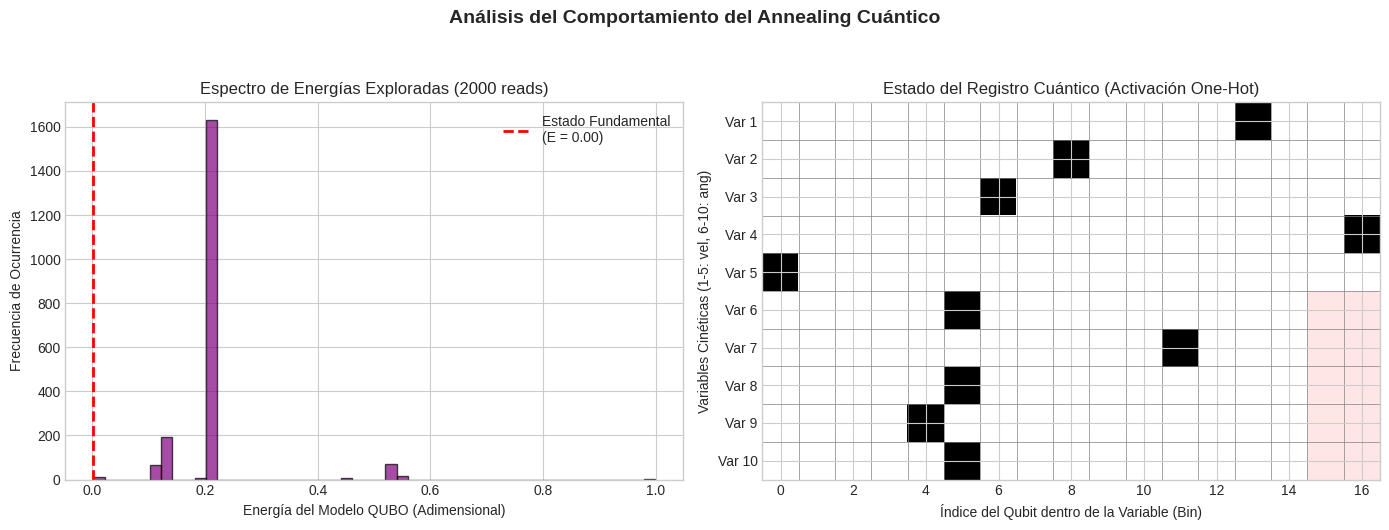

In [ ]:
import matplotlib.pyplot as plt


# Extraer el diccionario de la mejor muestra
solucion_binaria_dict = best_sample.sample
num_vars = modelo_cargado['num_vars_binarias']
vector_binario = np.zeros(num_vars, dtype=int)
for idx, val in solucion_binaria_dict.items():
    vector_binario[idx] = val


# Verificar que las variables existan
if 'sampleset' in locals() and 'vector_binario' in locals():

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Análisis del Comportamiento del Annealing Cuántico', fontsize=14, fontweight='bold', y=1.05)

    # ---------------------------------------------------------
    # Gráfica 1: Histograma del Espectro de Energías
    # ---------------------------------------------------------
    # Extraemos las energías de todas las lecturas
    energias = sampleset.record.energy

    ax1.hist(energias, bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax1.set_title("Espectro de Energías Exploradas (2000 reads)", fontsize=12)
    ax1.set_xlabel("Energía del Modelo QUBO (Adimensional)", fontsize=10)
    ax1.set_ylabel("Frecuencia de Ocurrencia", fontsize=10)

    # Marcar el estado fundamental (Ground State)
    min_energy = np.min(energias)
    ax1.axvline(min_energy, color='red', linestyle='dashed', linewidth=2,
                label=f'Estado Fundamental\n(E = {min_energy:.2f})')
    ax1.legend()

    # ---------------------------------------------------------
    # Gráfica 2: Visualización de los Qubits Activados (One-Hot)
    # ---------------------------------------------------------
    # Convertimos el vector 1D en un formato 2D para ver cómo se activaron los bins
    # Asumimos que hay 10 variables continuas en total (5 velocidades, 5 ángulos)
    # Creamos una matriz donde cada fila es una variable, y las columnas son los bins

    max_bins = max(n_bins_p, n_bins_u)
    matriz_qubits = np.full((10, max_bins), np.nan) # Llenamos con NaN los espacios vacíos

    idx_actual = 0
    for i in range(5): # Primeras 5 variables (velocidades)
        matriz_qubits[i, :n_bins_p] = vector_binario[idx_actual : idx_actual + n_bins_p]
        idx_actual += n_bins_p

    for i in range(5): # Últimas 5 variables (ángulos)
        matriz_qubits[i+5, :n_bins_u] = vector_binario[idx_actual : idx_actual + n_bins_u]
        idx_actual += n_bins_u

    # Graficar como un mapa de calor (Heatmap)
    cmap = plt.cm.get_cmap('Greys')
    cmap.set_bad(color='#ffe6e6') # Pintar de rojizo los bins que no existen (si n_bins_p != n_bins_u)

    cax = ax2.imshow(matriz_qubits, cmap=cmap, aspect='auto')

    # Estética de la grilla de qubits
    ax2.set_title("Estado del Registro Cuántico (Activación One-Hot)", fontsize=12)
    ax2.set_xlabel("Índice del Qubit dentro de la Variable (Bin)", fontsize=10)
    ax2.set_ylabel("Variables Cinéticas (1-5: vel, 6-10: ang)", fontsize=10)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels([f"Var {i+1}" for i in range(10)])

    # Líneas para simular una grilla cuántica
    ax2.set_xticks(np.arange(-.5, max_bins, 1), minor=True)
    ax2.set_yticks(np.arange(-.5, 10, 1), minor=True)
    ax2.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron los datos necesarios para generar las gráficas.")

---
## 7. Decodificación del Registro Cuántico y Validación Física

Una vez concluido el proceso de recocido (annealing), el sistema colapsa en un estado fundamental que se lee como una cadena de bits clásicos $q \in \{0,1\}^N$.

En esta etapa final, se lleva a cabo el siguiente protocolo de validación:
1. **Extracción del Estado Fundamental ($|q_{opt}\rangle$):** Se visualiza el vector binario resultante, observando qué *qubits* específicos se activaron para satisfacer las restricciones de penalización (exactamente un '1' por bloque variable).
2. **Mapeo Inverso ($q \to x$):** Se traduce la cadena binaria a los valores flotantes reales utilizando la estructuración del `KBinsDiscretizer`.
3. **Validación de Factibilidad Estricta ($\phi(x)$):** Como prueba irrefutable de que la formulación QUBO preservó la topología del problema original, el vector continuo decodificado se evalúa en la función de costo física $\phi(x)$. Un retorno numérico válido demuestra matemáticamente que la cadena binaria generada por el simulador cuántico corresponde a una trayectoria $100\%$ factible sin violar ninguna restricción aeronáutica.

In [ ]:
# NOTA: Asegúrate de tener importada tu función phi desde tu script de físicas
from 1_modelos_base.modelo_fisico_A320 import ϕ

print("\n" + "="*75)
print(" ANÁLISIS DEL ESTADO FUNDAMENTAL Y DECODIFICACIÓN DEL REGISTRO")
print("="*75)

# 1. Mostrar el estado en notación de Dirac (agrupado para mejor lectura)
estado_str = "".join(map(str, vector_binario))
# Formatear la salida para que no sature la pantalla si es muy larga
print(f"Estado cuántico colapsado |q_{{opt}}⟩ (longitud {num_vars} qubits):")
if num_vars > 60:
    print(f"|q_{{opt}}⟩ = |{estado_str[:30]} ... {estado_str[-30:]}⟩\n")
else:
    print(f"|q_{{opt}}⟩ = |{estado_str}⟩\n")

try:
    # 2. Inversión del discretizador
    punto_corte = 5 * n_bins_p
    vec_primeras = vector_binario.reshape(1, -1)[:, :punto_corte]
    vec_ultimas = vector_binario.reshape(1, -1)[:, punto_corte:]

    vals_primeras = modelo_cargado['discretizer_primeras'].inverse_transform(vec_primeras)
    vals_ultimas = modelo_cargado['discretizer_ultimas'].inverse_transform(vec_ultimas)

    valores_finales = np.hstack([vals_primeras, vals_ultimas])[0]
    valores_redondeados = np.round(valores_finales, 4)

    print("-" * 75)
    print(" MAPEO INVERSO: ESTADO BINARIO -> VARIABLES CONTINUAS")
    print("-" * 75)
    print(f"Vector continuo proyectado x ∈ ℝ^10:")
    print(f"x = {valores_redondeados.tolist()}\n")

    # 3. EVALUACIÓN FÍSICA EN LA FUNCIÓN ORIGINAL ϕ
    print("-" * 75)
    print(" VERIFICACIÓN DE FACTIBILIDAD EN EL MODELO CONTINUO ϕ(x)")
    print("-" * 75)

    costo_fisico_final = phi(*valores_finales)

    if np.isnan(costo_fisico_final) or costo_fisico_final > 0:
        print("[!] RESULTADO INVÁLIDO:")
        print("El estado binario decodificado viola las restricciones dinámicas o la envolvente de vuelo.")
    else:
        print("[✓] COMPROBACIÓN DE ISOMORFISMO EXITOSA:")
        print("El estado fundamental hallado por el modelo QUBO corresponde unívocamente")
        print("a una trayectoria física factible que satisface el 100% de las inecuaciones del modelo.")
        print(f"\n---> Costo de la trayectoria ϕ(x) = {costo_fisico_final:,.2f} kg")

except Exception as e:
    print(f"\n[!] Error durante la decodificación matemática: {e}")



ruta_archivo_optimo = ruta_carpeta + 'optimo_qc.txt'
# Guardando optimo QC
with open(ruta_archivo_optimo, 'w') as f:
    f.write(f"Costo Físico Final (ϕ): {costo_fisico_final} kg")



 ANÁLISIS DEL ESTADO FUNDAMENTAL Y DECODIFICACIÓN DEL REGISTRO
Estado cuántico colapsado |q_{opt}⟩ (longitud 160 qubits):
|q_{opt}⟩ = |000000000000010000000000010000 ... 000010000000000000001000000000⟩

---------------------------------------------------------------------------
 MAPEO INVERSO: ESTADO BINARIO -> VARIABLES CONTINUAS
---------------------------------------------------------------------------
Vector continuo proyectado x ∈ ℝ^10:
x = [220.6681, 239.5164, 235.0154, 247.6387, 192.0758, 2.568, 10.9177, 2.335, 1.9795, 13.9973]

---------------------------------------------------------------------------
 VERIFICACIÓN DE FACTIBILIDAD EN EL MODELO CONTINUO ϕ(x)
---------------------------------------------------------------------------
[✓] COMPROBACIÓN DE ISOMORFISMO EXITOSA:
El estado fundamental hallado por el modelo QUBO corresponde unívocamente
a una trayectoria física factible que satisface el 100% de las inecuaciones del modelo.

---> Costo de la trayectoria ϕ(x) = -58,936.